In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt 
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [10]:
data = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
data.shape


(42000, 785)

In [11]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

# 20/80 split for training/validation
dev_size = int(round(m*0.2))
data_dev = data[0:dev_size,:].T

Y_dev = data_dev[0,:]
X_dev = data_dev[1:n,:]/255

data_train = data[dev_size:m,:].T
Y_train = data_train[0,:]
X_train = data_train[1:n,:]/255
print(n)
print(m)

785
42000


In [16]:
# n = 785
# m = 42000
def init_param():
    W1 = np.random.rand(10,n-1) - 0.5
    b1 = np.random.rand(10,1) - 0.5
    W2 = np.random.rand(10,10) - 0.5
    b2 = np.random.rand(10,1) - 0.5
    return W1, b1, W2, b2



def ReLU(Z):
    return np.maximum(Z, 0)



def softmax(Z):
    A = np.exp(Z)/sum(np.exp(Z))
    return A




def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2


def derivative_ReLU(Z):
    return Z > 0


def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max()+1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y



def back_prop(Z1, A1, Z2, A2, W1, W2, X , Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1/m * dZ2.dot(A1.T)
    db2 = 1/m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * (derivative_ReLU(Z1))
    dW1 = 1/m * dZ1.dot(X.T)
    db1 = 1/m * np.sum(dZ1)
    return dW1, db1, dW2, db2


def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, W2, b1, b2


In [17]:
def get_prediction(A2):
    return np.argmax(A2,0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size


def gradient_descent (X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_param()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W1, W2, X , Y)
        W1, W2, b1, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if (i % 10 ==0):
            print("Iterations: ", i)
            predictions = get_prediction(A2)
            print("Accuracy:", get_accuracy(predictions,Y))
    return W1, b1, W2, b2


In [18]:
W1_final, b1_final, W2_final, b2_final = gradient_descent(X_train, Y_train, 500, 0.1)

Iterations:  0
[4 7 7 ... 8 8 9] [1 4 3 ... 6 5 2]
Accuracy: 0.05392857142857143
Iterations:  10
[4 7 3 ... 8 1 9] [1 4 3 ... 6 5 2]
Accuracy: 0.13202380952380952
Iterations:  20
[1 7 0 ... 8 1 3] [1 4 3 ... 6 5 2]
Accuracy: 0.2055952380952381
Iterations:  30
[1 7 0 ... 5 1 3] [1 4 3 ... 6 5 2]
Accuracy: 0.26708333333333334
Iterations:  40
[1 4 0 ... 5 1 3] [1 4 3 ... 6 5 2]
Accuracy: 0.31758928571428574
Iterations:  50
[1 4 0 ... 5 1 3] [1 4 3 ... 6 5 2]
Accuracy: 0.3580357142857143
Iterations:  60
[1 4 3 ... 5 1 3] [1 4 3 ... 6 5 2]
Accuracy: 0.39339285714285716
Iterations:  70
[1 4 3 ... 5 1 3] [1 4 3 ... 6 5 2]
Accuracy: 0.4261309523809524
Iterations:  80
[1 4 3 ... 5 1 3] [1 4 3 ... 6 5 2]
Accuracy: 0.4563392857142857
Iterations:  90
[1 4 3 ... 5 1 3] [1 4 3 ... 6 5 2]
Accuracy: 0.4836011904761905
Iterations:  100
[1 4 3 ... 5 1 3] [1 4 3 ... 6 5 2]
Accuracy: 0.5088690476190476
Iterations:  110
[1 4 3 ... 6 8 3] [1 4 3 ... 6 5 2]
Accuracy: 0.5317261904761905
Iterations:  120
[1 4 

8


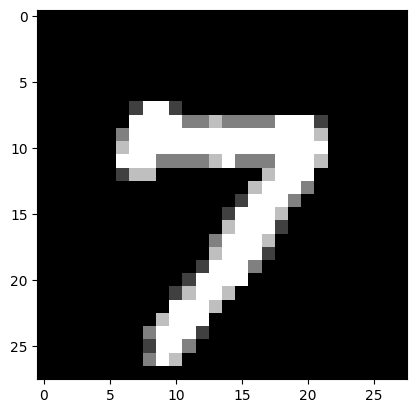

In [162]:
plt.gray()
plt.imshow(X_train[:,30].reshape((28,28))*255, interpolation = "nearest")
print(Y_train[1])

In [163]:
print(Y_train[30])

7
